In [ ]:
%run data_ingestion.ipynb

**Exploring the data**

In [ ]:
df.shape


(30000, 25)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   id                          30000 non-null  int64
 1   limit_bal                   30000 non-null  int64
 2   sex                         30000 non-null  int64
 3   education                   30000 non-null  int64
 4   marriage                    30000 non-null  int64
 5   age                         30000 non-null  int64
 6   pay_0                       30000 non-null  int64
 7   pay_2                       30000 non-null  int64
 8   pay_3                       30000 non-null  int64
 9   pay_4                       30000 non-null  int64
 10  pay_5                       30000 non-null  int64
 11  pay_6                       30000 non-null  int64
 12  bill_amt1                   30000 non-null  int64
 13  bill_amt2                   30000 non-null  int64
 14  bill_a

In [ ]:
df.describe()

,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,143967.333333,1.505633,2.063133,1.650933,44.801067,0.181933,0.199600,0.183167,0.183667,...,75612.391133,75690.268600,75334.072833,57038.644700,56905.105333,56164.425300,56889.927567,56782.113900,56449.786600,0.431467
std,8660.398374,147168.391819,0.499977,0.868585,0.653376,14.127100,1.124282,1.127092,1.132987,1.125807,...,92104.552106,92015.585477,92020.045745,77231.656714,76762.872293,74359.768818,76057.669578,75377.598097,75681.186287,0.495289
min,1.000000,10000.000000,1.000000,1.000000,1.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,1002.000000,1004.000000,1000.000000,335.000000,370.000000,327.000000,352.000000,325.000000,361.000000,0.000000
25%,7500.750000,30000.000000,1.000000,1.000000,1.000000,33.000000,0.000000,0.000000,0.000000,0.000000,...,14236.750000,14154.500000,14038.500000,9429.000000,9414.500000,9444.500000,9394.750000,9340.000000,9385.750000,0.000000
50%,15000.500000,80000.000000,2.000000,2.000000,2.000000,45.000000,0.000000,0.000000,0.000000,0.000000,...,39892.000000,40206.500000,40105.500000,27270.500000,27110.500000,27507.000000,27254.000000,27620.500000,27070.500000,0.000000
75%,22500.250000,200000.000000,2.000000,3.000000,2.000000,57.000000,0.000000,1.000000,0.000000,0.000000,...,98930.500000,98134.000000,97164.250000,71481.000000,71454.000000,71341.250000,71176.000000,72238.500000,71680.750000,1.000000
max,30000.000000,500000.000000,2.000000,4.000000,3.000000,69.000000,4.000000,4.000000,4.000000,4.000000,...,474879.000000,474933.000000,474919.000000,566049.000000,555450.000000,556395.000000,559512.000000,556775.000000,554430.000000,1.000000


In [ ]:
target_col = "default_payment_next_month"

df[target_col].value_counts()

default_payment_next_month
0    17056
1    12944
Name: count, dtype: int64

In [ ]:
df[target_col].value_counts(normalize=True)

default_payment_next_month
0    0.568533
1    0.431467
Name: proportion, dtype: float64

**Check for missing values and duplicates**

In [ ]:
df.isnull().sum()

id                            0
limit_bal                     0
sex                           0
education                     0
marriage                      0
age                           0
pay_0                         0
pay_2                         0
pay_3                         0
pay_4                         0
pay_5                         0
pay_6                         0
bill_amt1                     0
bill_amt2                     0
bill_amt3                     0
bill_amt4                     0
bill_amt5                     0
bill_amt6                     0
pay_amt1                      0
pay_amt2                      0
pay_amt3                      0
pay_amt4                      0
pay_amt5                      0
pay_amt6                      0
default_payment_next_month    0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

**Rename columns for cleaner usage**

In [ ]:
df.columns = [
    col.lower()
       .replace(" ", "_")
       .replace(".", "_")
       .replace("-", "_")
    for col in df.columns
]

df.columns

Index(['id', 'limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_0',
       'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2',
       'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1',
       'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6',
       'default_payment_next_month'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   id                          30000 non-null  int64
 1   limit_bal                   30000 non-null  int64
 2   sex                         30000 non-null  int64
 3   education                   30000 non-null  int64
 4   marriage                    30000 non-null  int64
 5   age                         30000 non-null  int64
 6   pay_0                       30000 non-null  int64
 7   pay_2                       30000 non-null  int64
 8   pay_3                       30000 non-null  int64
 9   pay_4                       30000 non-null  int64
 10  pay_5                       30000 non-null  int64
 11  pay_6                       30000 non-null  int64
 12  bill_amt1                   30000 non-null  int64
 13  bill_amt2                   30000 non-null  int64
 14  bill_a

In [ ]:
df.shape

(30000, 25)

In [ ]:
# Count each class
print(df["default_payment_next_month"].value_counts())

# Percentage distribution
print(df["default_payment_next_month"].value_counts(normalize=True) * 100)

default_payment_next_month
0    17056
1    12944
Name: count, dtype: int64
default_payment_next_month
0    56.853333
1    43.146667
Name: proportion, dtype: float64


**Yes-1,No-0**
**Yes count-6636, No count-23364**
**78%-No, 22%-Yes**

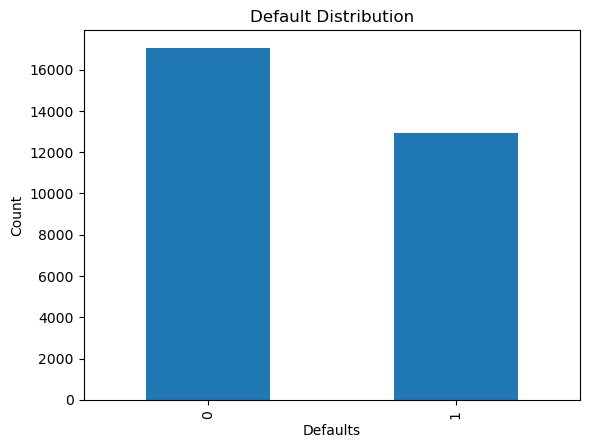

In [ ]:
import matplotlib.pyplot as plt

df["default_payment_next_month"].value_counts().plot(kind="bar")
plt.title("Default Distribution")
plt.xlabel("Defaults")
plt.ylabel("Count")
plt.show()

In [ ]:
counts = df["default_payment_next_month"].value_counts()

majority = counts.max()
minority = counts.min()

print(f"Imbalance Ratio: {majority/minority:.2f}:1")

Imbalance Ratio: 1.32:1


This means there are 1.32 defaults for every default